In [385]:
# Import modules
import sys
sys.path.append(r"c:/Users/Raees/Desktop/stuff/NuOscProbExact/src")

from oscprob2nu import *
from globaldefs import *
from hamiltonians2nu import *

import numpy as np 
import matplotlib.pyplot as plt
import math
from scipy.stats import truncnorm
from scipy.optimize import curve_fit
from scipy.integrate import simpson, quad
import copy as cp

In [386]:
# Gaussian fit
def gaus(data, amplitude, mean, sigma):
    return amplitude * math.e**((-0.5 * (data - mean)**2) / sigma**2)

def fluctuated_fit(gaus, bin_centers, counts):
    popt, _ = curve_fit(gaus, bin_centers, counts)
    return popt

In [387]:
# Parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5])
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5])
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])

adjusted_counts_fd = np.array([ 0.  ,  7.5 ,  1.  ,  3.  ,  1.  ,  2.  ,  2.  ,  4.  ,  6.  ,
        9.  , 15.  , 12.  , 39.5 , 25.  , 19.25, 20.25, 16.  , 14.  ,
       18.  ])
adjusted_counts_nd = np.array([ 37500., 105000.,  72000.,  96000., 120000., 148000., 170000.,
       192000., 208000., 214000., 212000., 204000., 425000., 280000.,
       181500.,  81000.,  80000.,  25000.,  10000.])

counts_nd_e = np.array([0.4, 2, 3.8, 5.75, 3.4, 1.8, 1 ,0.9, 0.75])
bin_edges_e = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5])

length_nd = 1 # [km]
length_fd = 810 # [km]

print(np.sum(adjusted_counts_nd))
print(np.sum(adjusted_counts_fd))
print(np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd))

print(np.sum(counts_fd) / np.sum(counts_nd))
print(adjusted_counts_fd / adjusted_counts_nd)

print((adjusted_counts_fd / 7.497378538972387e-05))

print(counts_fd/ max(counts_fd))

print(np.sum(counts_nd))


2861000.0
214.5
7.497378538972387e-05
0.05150789851603638
[0.00000000e+00 7.14285714e-05 1.38888889e-05 3.12500000e-05
 8.33333333e-06 1.35135135e-05 1.17647059e-05 2.08333333e-05
 2.88461538e-05 4.20560748e-05 7.07547170e-05 5.88235294e-05
 9.29411765e-05 8.92857143e-05 1.06060606e-04 2.50000000e-04
 2.00000000e-04 5.60000000e-04 1.80000000e-03]
[     0.         100034.96503497  13337.995338    40013.98601399
  13337.995338    26675.99067599  26675.99067599  53351.98135198
  80027.97202797 120041.95804196 200069.93006993 160055.94405594
 526850.81585082 333449.88344988 256756.41025641 270094.40559441
 213407.92540793 186731.93473193 240083.91608392]
[0.         0.18987342 0.06329114 0.18987342 0.06329114 0.12658228
 0.12658228 0.25316456 0.37974684 0.56962025 0.94936709 0.75949367
 1.         0.63291139 0.44303797 0.56962025 0.20253165 0.17721519
 0.11392405]
2089


Fitted parameters for observed the unoscillated ND events: Amplitude = 212.76692699546734, Mean = 1.8044188236655974, Sigma = 0.5254484171717854
Fitted parameters for observed the unoscillated ND events: Amplitude = 13.876682332452186, Mean = 2.2114226340866225, Sigma = -0.49524730606517153


Text(0.5, 0, 'Energy (GeV)')

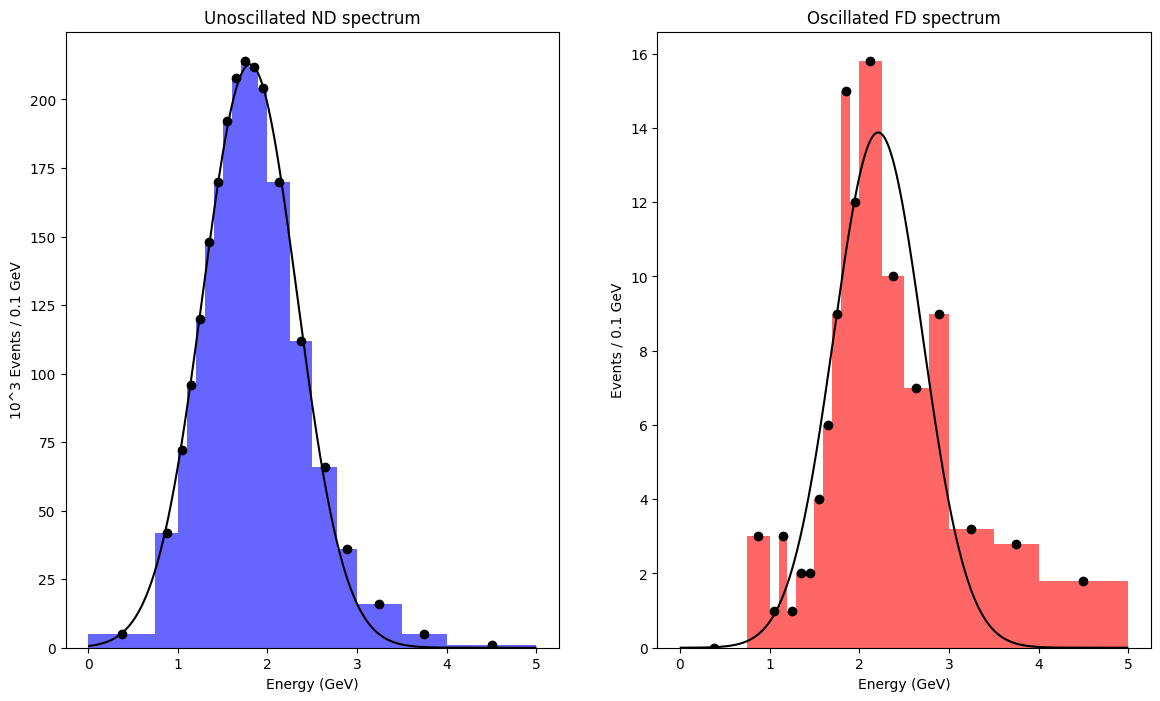

In [388]:
# Finding the Gaussian fit for the observed energy spectrum

initial_guess = [140, 2, 0.5]

popt_nd, _ = curve_fit(gaus, bin_centers, counts_nd, p0=initial_guess)
print(f"Fitted parameters for observed the unoscillated ND events: Amplitude = {popt_nd[0]}, Mean = {popt_nd[1]}, Sigma = {popt_nd[2]}")

popt_fd, _ =curve_fit(gaus, bin_centers, counts_fd)
print(f"Fitted parameters for observed the unoscillated ND events: Amplitude = {popt_fd[0]}, Mean = {popt_fd[1]}, Sigma = {popt_fd[2]}")


fig, axs = plt.subplots(1, 2, figsize=(14, 8))

x = np.arange(0.01,5,0.01)

axs[0].hist(bin_edges[:-1],bin_edges ,weights=counts_nd, density=False, alpha=0.6, color='b')
axs[0].scatter(bin_centers, counts_nd, color='black')
axs[0].plot(x, gaus(x,*popt_nd), color='black')
axs[0].set_title("Unoscillated ND spectrum")
axs[0].set_ylabel("10^3 Events / 0.1 GeV")
axs[0].set_xlabel("Energy (GeV)")

axs[1].hist(bin_edges[:-1], bin_edges,weights=counts_fd, density=False, alpha=0.6, color='r')
axs[1].scatter(bin_centers, counts_fd, color='black')
axs[1].plot(x, gaus(x,*popt_fd), color='black')
axs[1].set_title("Oscillated FD spectrum")
axs[1].set_ylabel("Events / 0.1 GeV")
axs[1].set_xlabel("Energy (GeV)")

print(np.sum(gaus(x,*popt_fd)))
print(np.sum(gaus(x,*popt_nd)))

print(np.sum((counts_fd/ max(counts_fd)) * gaus(bin_centers, *popt_fd)))

plt.figure()
plt.plot(bin_centers, ((counts_fd/ max(counts_fd)) * gaus(bin_centers, *popt_fd)))
plt.show()


In [389]:
def osc_prob_2nu(sector, case, length, transition):

    popt = popt_nd
    energy = x * 1e9
    probabilities = []

    # Sector-specific parameters
    if sector == '12':
        mixing_angle = S12_NO_BF
        delta_mass_squared = D21_NO_BF
        transition_map = {'me': 2, 'mm': 3}
    elif sector == '23':
        mixing_angle = S23_NO_BF
        delta_mass_squared = D31_NO_BF
        transition_map = {'mm': 0, 'mt': 1}
    else:
        raise ValueError(f"Invalid sector '{sector}'. Must be '12' or '23'.")

    # Determine the index for the transition
    index = transition_map.get(transition)
    if index is None:
        raise ValueError(f"Invalid transition '{transition}'. Must match the sector.")
    
    # Calculate energy-independent vacuum Hamiltonian
    h_vacuum_energy_indep = hamiltonian_2nu_vacuum_energy_independent(mixing_angle, delta_mass_squared)
    length_scaled = length * CONV_KM_TO_INV_EV

    # Define a function for Hamiltonian calculation
    if case == 'vacuum':
        def calculate_hamiltonian(e): 
            return h_vacuum_energy_indep / e
    elif case == 'matter':
        def calculate_hamiltonian(e): return hamiltonian_2nu_matter(h_vacuum_energy_indep, e, VCC_EARTH_CRUST)
    else:
        raise ValueError(f"Invalid case '{case}'. Must be 'vacuum' or 'matter'.")

    # Compute probabilities
    probabilities = [
        probabilities_2nu(calculate_hamiltonian(e), length_scaled)[index]
        for e in energy
    ]
    
    gaus_fit = probabilities * gaus(x, *popt)

    #fluc_gaus_fit = np.random.poisson(gaus_fit)
    print('Sum of fit (without scaling)', np.sum(gaus_fit))
    areas = []
    fluc_areas = []

    if length == length_fd:
        gaus_fit = gaus_fit 
        
        #* ((np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd)) / (5558.977756872476 / 28014.986447888423))  
        # # *7.497378538972387e-05 #* (7.497378538972387e-05 / (5558.977756872476 / 28014.986447888423) * 102)

        print('sum of fit', np.sum(gaus_fit))
    for i in range(1, len(bin_edges)):

        x_min, x_max = bin_edges[i-1], bin_edges[i]
        mask = (x >= x_min) & (x <= x_max)

        x_range = x[mask]
        y_range = gaus_fit[mask]
        #fluc_y_range = fluc_gaus_fit[mask]

        area = np.trapz(y_range, x_range)
        areas.append(area)

        #fluc_area = simps(fluc_y_range, x_range)
        #fluc_areas.append(fluc_area)

    bin_widths = np.diff(bin_edges)
    print('Areas = ', areas)
    areas = np.array(areas)
    print('Sum of areas = ', np.sum(areas))

    scale_factor = 0.19

    if length == length_fd:
        if transition == 'mt':
            areas[10] += 2
        counts = (areas / bin_widths) *7.497378538972387e-05 * (1000 * 28014.98644788842/5558.977756872476)
        
    elif length == length_nd:
        areas[10] += 2
        counts = areas / bin_widths
    
    print('Counts = ', counts)
    print('Sum of counts = ', np.sum(counts))
    fluc_counts = np.random.poisson(counts)


    return gaus_fit, counts, fluc_counts

Sum of fit (without scaling) 28014.986447888423
Areas =  [6.1861787048651635, 11.351403763903976, 7.602939082119747, 9.8049436759435, 12.196271736099131, 13.062216737810543, 16.93348713087606, 18.900956373870898, 20.348840439465157, 21.130709272210172, 19.068255050206425, 20.446476447965953, 43.897298261124874, 29.545828592387135, 16.738886098857282, 5.6717173037101, 3.0317481685669385, 0.17127462044182026, 0.004113861343430399]
Sum of areas =  276.0935453217683
Counts =  [8.24823827e+00 4.54056151e+01 7.60293908e+01 9.80494368e+01
 1.21962717e+02 1.30622167e+02 1.69334871e+02 1.89009564e+02
 2.03488404e+02 2.11307093e+02 2.10682551e+02 2.04464764e+02
 1.75589193e+02 1.18183314e+02 6.08686767e+01 2.52076325e+01
 6.06349634e+00 3.42549241e-01 4.11386134e-03]
Sum of counts =  2054.8637888319054
Number of points 499
sum of fit 28014.986447888423
Total area =  280.14677665948295
Area under the curve between x=0.0 and x=0.75: 6.185308409287006
Area under the curve between x=0.75 and x=1.0: 

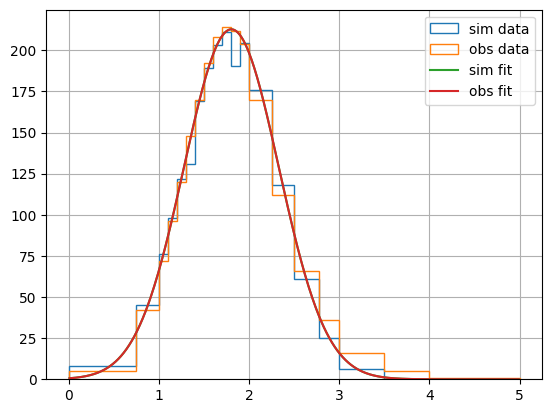

[6.185308409287006, 11.350707366866699, 7.602697639479996, 9.804782410583467, 12.196231356504644, 13.062309259169528, 16.93376557213071, 18.901392234780374, 20.349400108192626, 21.131338407386334, 21.018826087993475, 20.447044693881733, 43.89812446273177, 29.545691551377594, 16.738172049571332, 5.671176242696656, 3.031231080039354, 0.17121723349927648, 0.004111582897309761]
278.0435277490699


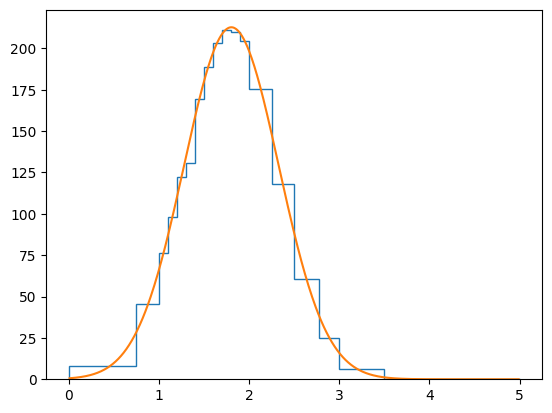

In [390]:
gaus_fit, _, _ = osc_prob_2nu('12', 'vacuum', length_nd, 'mm')
print('Number of points',len(gaus_fit))
print('sum of fit',np.sum(gaus_fit))
#print(np.sum(gaus(x, *popt_nd)))

bin_widths = np.diff(bin_edges)
scaling_factor = bin_widths
#print(bin_widths)

total_area = simpson(gaus_fit, x=x)
print('Total area = ', total_area)

counts = []
for i in range(1, len(bin_edges)):

    x_min, x_max = bin_edges[i-1], bin_edges[i]
    mask = (x >= x_min) & (x <= x_max)

    x_range = x[mask]
    y_range = gaus_fit[mask]

    area = simpson(y_range, x_range)
    print(f"Area under the curve between x={x_min} and x={x_max}: {area}")
    counts.append(area)


print('Counts = ', counts)

print('Total area ratio = ', (np.sum(counts) / total_area) * 100)
print('Sum of areas = ', np.sum(counts))
print(counts / scaling_factor)
print('counts',np.sum(counts))
print('counts with scaling', np.sum(counts / scaling_factor))
print(np.sum(counts_nd))

fluc_counts = np.random.poisson(counts)
print('Fluctuated counts = ', fluc_counts)

plt.figure()
plt.hist(bin_edges[:-1], bin_edges, weights=(counts / scaling_factor), histtype='step', label='sim data')
plt.hist(bin_edges[:-1], bin_edges, weights=counts_nd, histtype='step', label='obs data')
plt.plot(x,gaus_fit, label='sim fit')
plt.plot(x, gaus(x, *popt_nd), label='obs fit')
plt.legend()
plt.grid()
plt.show()

counts[10] += 1.95
print(counts)
print(np.sum(counts))
plt.figure()
plt.hist(bin_edges[:-1], bin_edges, weights=(counts / scaling_factor), histtype='step', label='sim data')
plt.plot(x, gaus_fit, label='obs fit')


Sum of fit (without scaling) 28014.986447888423
Areas =  [6.1861787048651635, 11.351403763903976, 7.602939082119747, 9.8049436759435, 12.196271736099131, 13.062216737810543, 16.93348713087606, 18.900956373870898, 20.348840439465157, 21.130709272210172, 19.068255050206425, 20.446476447965953, 43.897298261124874, 29.545828592387135, 16.738886098857282, 5.6717173037101, 3.0317481685669385, 0.17127462044182026, 0.004113861343430399]
Sum of areas =  276.0935453217683
Counts =  [8.24823827e+00 4.54056151e+01 7.60293908e+01 9.80494368e+01
 1.21962717e+02 1.30622167e+02 1.69334871e+02 1.89009564e+02
 2.03488404e+02 2.11307093e+02 2.10682551e+02 2.04464764e+02
 1.75589193e+02 1.18183314e+02 6.08686767e+01 2.52076325e+01
 6.06349634e+00 3.42549241e-01 4.11386134e-03]
Sum of counts =  2054.8637888319054


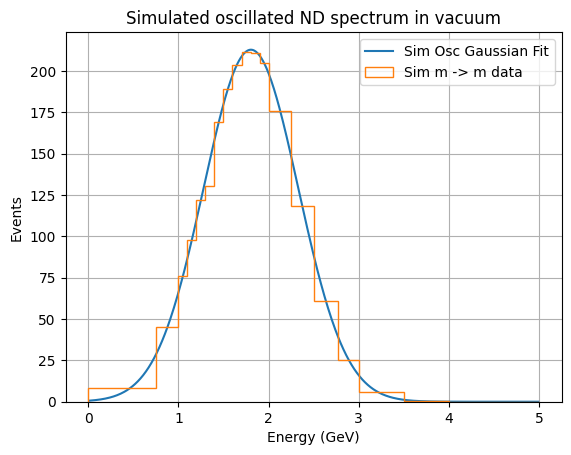

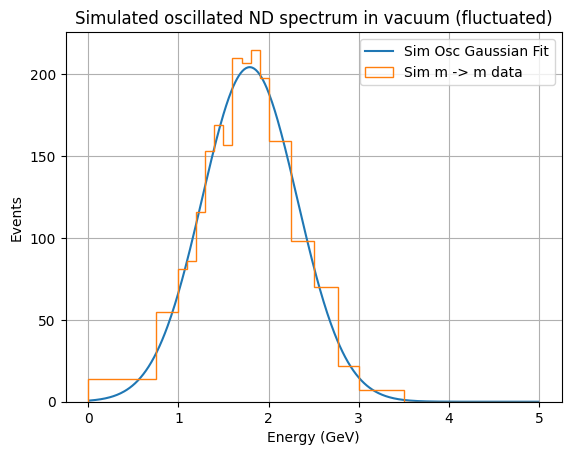

In [391]:
sim_fit_nd, sim_counts_nd, sim_fluc_counts_nd = osc_prob_2nu('12', 'vacuum', length_nd, 'mm')


plt.figure()

plt.plot(x, sim_fit_nd, label='Sim Osc Gaussian Fit')
plt.hist(bin_edges[:-1], bin_edges, weights=sim_counts_nd, histtype='step', label='Sim m -> m data')

plt.title('Simulated oscillated ND spectrum in vacuum')
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.grid()
plt.legend()
plt.show()

plt.figure()

plt.plot(x, gaus(x, *fluctuated_fit(gaus, bin_centers, sim_fluc_counts_nd)), label='Sim Osc Gaussian Fit')
plt.hist(bin_edges[:-1], bin_edges, weights=sim_fluc_counts_nd, histtype='step', label='Sim m -> m data')

plt.title('Simulated oscillated ND spectrum in vacuum (fluctuated)')
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.grid()
plt.legend()
plt.show()

Sum of fit (without scaling) 28014.986447888467
Areas =  [6.186178704865421, 11.35140376390398, 7.6029390821197484, 9.8049436759435, 12.196271736099135, 13.062216737810544, 16.933487130876063, 18.900956373870898, 20.348840439465157, 21.130709272210172, 19.068255050206425, 20.446476447965953, 43.897298261124874, 29.545828592387135, 16.738886098857282, 5.6717173037101, 3.0317481685669385, 0.17127462044182026, 0.004113861343430399]
Sum of areas =  276.0935453217686
Counts =  [8.24823827e+00 4.54056151e+01 7.60293908e+01 9.80494368e+01
 1.21962717e+02 1.30622167e+02 1.69334871e+02 1.89009564e+02
 2.03488404e+02 2.11307093e+02 2.10682551e+02 2.04464764e+02
 1.75589193e+02 1.18183314e+02 6.08686767e+01 2.52076325e+01
 6.06349634e+00 3.42549241e-01 4.11386134e-03]
Sum of counts =  2054.863788831906


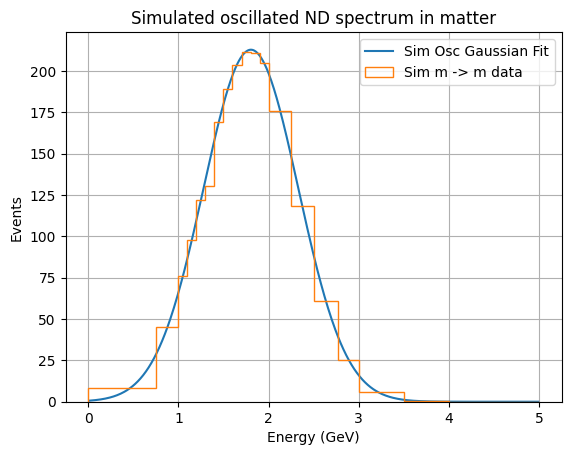

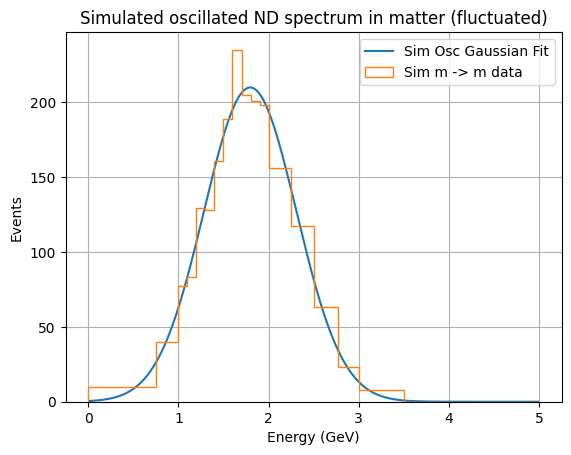

In [392]:
sim_fit_nd_matter, sim_counts_nd_matter, sim_fluc_counts_nd_matter = osc_prob_2nu('12', 'matter', length_nd, 'mm')


plt.figure()

plt.plot(x, sim_fit_nd, label='Sim Osc Gaussian Fit')
plt.hist(bin_edges[:-1], bin_edges, weights=sim_counts_nd_matter, histtype='step', label='Sim m -> m data')

plt.title('Simulated oscillated ND spectrum in matter')
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.grid()
plt.legend()
plt.show()

plt.figure()

plt.plot(x, gaus(x, *fluctuated_fit(gaus, bin_centers, sim_fluc_counts_nd_matter)), label='Sim Osc Gaussian Fit')
plt.hist(bin_edges[:-1], bin_edges, weights=sim_fluc_counts_nd_matter, histtype='step', label='Sim m -> m data')

plt.title('Simulated oscillated ND spectrum in matter (fluctuated)')
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.grid()
plt.legend()
plt.show()

Sum of fit (without scaling) 5558.977756872476
sum of fit 5558.977756872476
Areas =  [3.070785783386632, 10.261923232289275, 4.689373509780166, 4.041727966870329, 3.075330460502967, 1.89925843288114, 1.2289517190430825, 0.7119831656075567, 0.5625363519135698, 0.7461736114748239, 1.026478863369864, 1.6937749291610285, 6.164938028567662, 6.799469907937801, 5.344966137576592, 2.275382044122949, 1.4466741970442605, 0.09968682842226015, 0.002723073160403335]
Sum of areas =  55.142138243112356
Counts =  [1.54701020e+00 1.55093527e+01 1.77182059e+01 1.52711590e+01
 1.16197480e+01 7.17610827e+00 4.64343896e+00 2.69013853e+00
 2.12547260e+00 2.81932281e+00 3.87842083e+00 6.39971479e+00
 9.31737609e+00 1.02763755e+01 7.34373815e+00 3.82099727e+00
 1.09321517e+00 7.53308198e-02 1.02887882e-03]
Sum of counts =  123.32615448204106
Sum counts_fd =  107.6


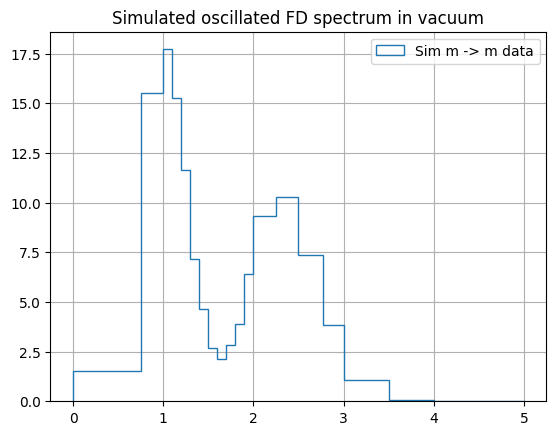

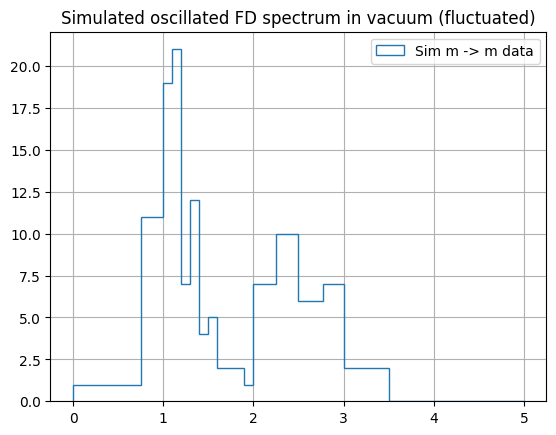

In [393]:
sim_fit_fd_mm, sim_counts_fd_mm, sim_fluc_counts_fd_mm = osc_prob_2nu('23', 'vacuum', length_fd, 'mm')
print('Sum counts_fd = ',np.sum(counts_fd))


plt.figure()

#plt.plot(x, sim_fit_fd_mm, label='Sim Osc Gaussian Fit')
plt.hist(bin_edges[:-1], bin_edges, weights=sim_counts_fd_mm, histtype='step', label='Sim m -> m data')
#plt.hist(bin_edges[:-1], bin_edges, weights=counts_fd, histtype='step', label='obs FD data')

plt.title('Simulated oscillated FD spectrum in vacuum')
plt.legend()
plt.grid()
plt.show()

plt.figure()

#plt.plot(x, gaus(x, *fluctuated_fit(gaus, bin_centers, sim_fluc_counts_fd_mm)), label='Sim Osc Gaussian Fit')
plt.hist(bin_edges[:-1], bin_edges, weights=sim_fluc_counts_fd_mm, histtype='step', label='Sim m -> m data')

plt.title('Simulated oscillated FD spectrum in vacuum (fluctuated)')
plt.legend()
plt.grid()
plt.show()

Sum of fit (without scaling) 22456.008869349294
sum of fit 22456.008869349294
Areas =  [3.1153936821393358, 1.089480640678379, 2.9135656239520786, 5.7632157645910915, 9.120941334074818, 11.162958359053942, 15.704535472220947, 18.1889732672711, 19.786304143629888, 20.384535712517824, 18.041776228879897, 18.752701559179336, 37.73236030613417, 22.746358724198895, 11.393919979657822, 3.396335264743067, 1.5850739738184678, 0.07158779211734813, 0.0013907881848536174]
Sum of areas =  220.95140861704328
Counts =  [1.56948291e+00 1.64658604e+00 1.10085400e+01 2.17755834e+01
 3.44623256e+01 4.21778292e+01 5.93376051e+01 6.87247397e+01
 7.47600528e+01 7.70203953e+01 7.57253219e+01 7.08547159e+01
 5.70267844e+01 3.43776982e+01 1.56547231e+01 5.70338850e+00
 1.19780039e+00 5.40970874e-02 5.25491762e-04]
Sum of counts =  653.078194992622


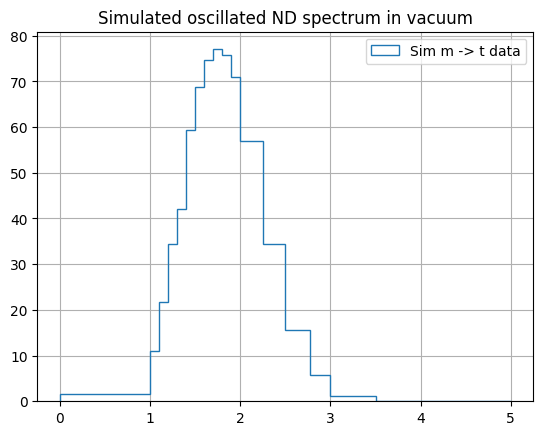

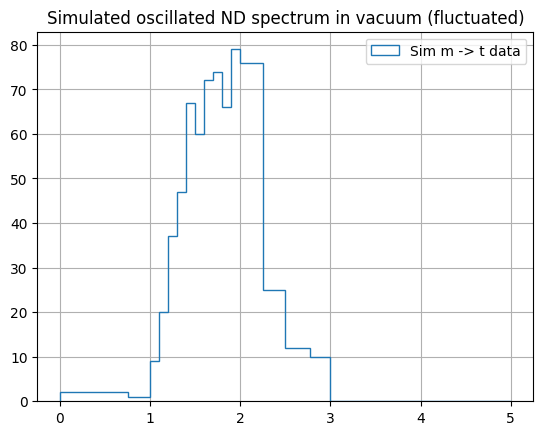

In [394]:
sim_fit_fd_mt, sim_counts_fd_mt, sim_fluc_counts_fd_mt = osc_prob_2nu('23', 'vacuum', length_fd, 'mt')


plt.figure()

#plt.plot(x, sim_fit_fd_mt, label='Sim Osc Gaussian Fit')
plt.hist(bin_edges[:-1], bin_edges, weights=sim_counts_fd_mt, histtype='step', label='Sim m -> t data')

plt.title('Simulated oscillated ND spectrum in vacuum')
plt.legend()
plt.grid()
plt.show()

plt.figure()

#plt.plot(x, gaus(x, *fluctuated_fit(gaus, bin_centers, sim_fluc_counts_fd_mt)), label='Sim Osc Gaussian Fit')
plt.hist(bin_edges[:-1], bin_edges, weights=sim_fluc_counts_fd_mt, histtype='step', label='Sim m -> t data')

plt.title('Simulated oscillated ND spectrum in vacuum (fluctuated)')
plt.legend()
plt.grid()
plt.show()

Sum of fit (without scaling) 70.7100092225771
sum of fit 70.7100092225771
Areas =  [0.18782204151401444, 0.07137628610022886, 0.03380406088836509, 0.03637248425872369, 0.038320742287522226, 0.0354734583197494, 0.03958438613358571, 0.03868406254969422, 0.03676702925518818, 0.03395318385979663, 0.02756907730153562, 0.026476272240500514, 0.048253071097884556, 0.02607068921788058, 0.012053842820802966, 0.0033820097300097233, 0.001505974586595424, 6.414932082637996e-05, 1.1982660950527134e-06]
Sum of areas =  0.6975340197489993
Counts =  [9.46215837e-02 1.07874515e-01 1.27724377e-01 1.37428841e-01
 1.44790088e-01 1.34031985e-01 1.49564607e-01 1.46162848e-01
 1.38919579e-01 1.28287820e-01 1.04166279e-01 1.00037253e-01
 7.29272555e-02 3.94019235e-02 1.65614268e-02 5.67933195e-03
 1.13802698e-03 4.84760224e-05 4.52749720e-07]
Sum of counts =  1.6493666691471216


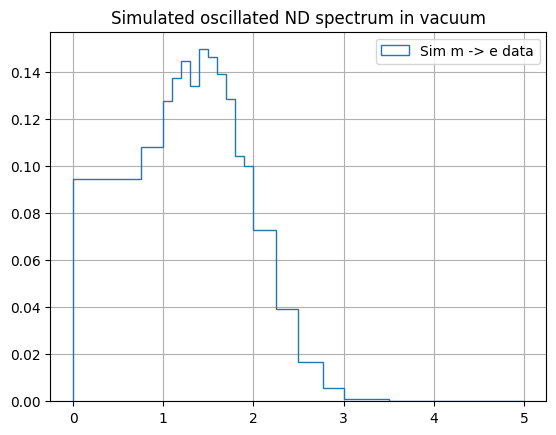

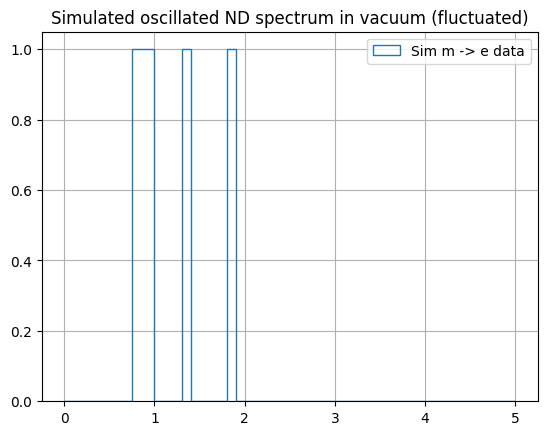

In [395]:
sim_fit_fd_me, sim_counts_fd_me, sim_fluc_counts_fd_me = osc_prob_2nu('12', 'vacuum', length_fd, 'me')


plt.figure()

#plt.plot(x, sim_fit_fd_mt, label='Sim Osc Gaussian Fit')
plt.hist(bin_edges[:-1], bin_edges, weights=sim_counts_fd_me, histtype='step', label='Sim m -> e data')

plt.title('Simulated oscillated ND spectrum in vacuum')
plt.legend()
plt.grid()
plt.show()

plt.figure()

#plt.plot(x, gaus(x, *fluctuated_fit(gaus, bin_centers, sim_fluc_counts_fd_me)), label='Sim Osc Gaussian Fit')
plt.hist(bin_edges[:-1], bin_edges, weights=sim_fluc_counts_fd_me, histtype='step', label='Sim m -> e data')

plt.title('Simulated oscillated ND spectrum in vacuum (fluctuated)')
plt.legend()
plt.grid()
plt.show()

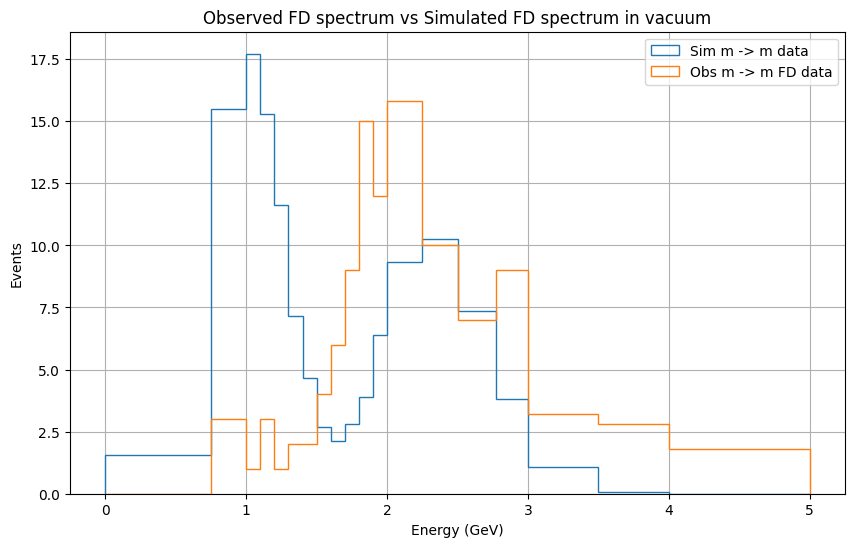

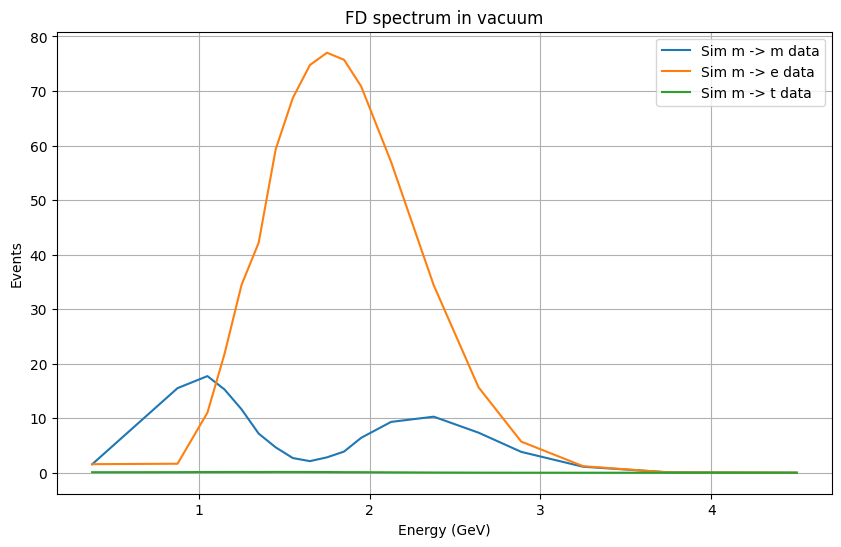

In [396]:
plt.figure(figsize=(10,6))
plt.hist(bin_edges[:-1], bin_edges, weights=sim_counts_fd_mm, histtype='step', label='Sim m -> m data')
plt.hist(bin_edges[:-1], bin_edges, weights=counts_fd, histtype='step', label='Obs m -> m FD data')

plt.title('Observed FD spectrum vs Simulated FD spectrum in vacuum')
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.grid()
plt.legend()
plt.show()


plt.figure(figsize=(10,6))

plt.plot(bin_centers,sim_counts_fd_mm, label='Sim m -> m data')
plt.plot(bin_centers,sim_counts_fd_mt, label='Sim m -> e data')
plt.plot(bin_centers,sim_counts_fd_me, label='Sim m -> t data')

plt.title("FD spectrum in vacuum")
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.grid()
plt.legend()
plt.show()

In [397]:
sim_fit_fd_mm_matter, sim_counts_fd_mm_matter, sim_fluc_counts_fd_mm_matter = osc_prob_2nu('23', 'matter', length_fd, 'mm')
sim_fit_fd_mt_matter, sim_counts_fd_mt_matter, sim_fluc_counts_fd_mt_matter = osc_prob_2nu('23', 'matter', length_fd, 'mt')
sim_fit_fd_me_matter, sim_counts_fd_me_matter, sim_fluc_counts_fd_me_matter = osc_prob_2nu('12', 'matter', length_fd, 'me')

Sum of fit (without scaling) 4997.889544370427
sum of fit 4997.889544370427
Areas =  [3.103995372449531, 10.108920517333608, 4.422164233355812, 3.6562442317619905, 2.5951727156666826, 1.4125140176049384, 0.658126021121693, 0.14621613057597652, 0.02980378074770825, 0.2673123384481018, 0.6523505972509173, 1.353518979980742, 5.608235431845016, 6.5532600319769205, 5.257010057081169, 2.2577527392411247, 1.4418364537514743, 0.09967719536547864, 0.0027259701501487]
Sum of areas =  49.62683681570905
Counts =  [1.56374063e+00 1.52781121e+01 1.67085894e+01 1.38146573e+01
 9.80553255e+00 5.33700593e+00 2.48664610e+00 5.52459194e-01
 1.12609824e-01 1.01000593e+00 2.46482439e+00 5.11410063e+00
 8.47600389e+00 9.90426636e+00 7.22289054e+00 3.79139278e+00
 1.08955941e+00 7.53235403e-02 1.02997341e-03]
Sum of counts =  104.80875053783687
Sum of fit (without scaling) 23017.097081851345
sum of fit 23017.097081851345
Areas =  [3.0821840930764353, 1.2424833556340444, 3.1807749003764325, 6.14869949969943, 

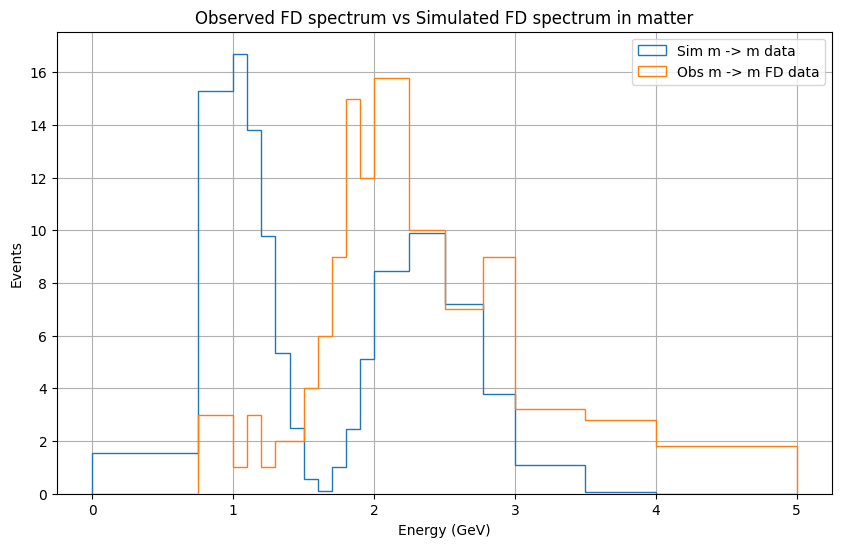

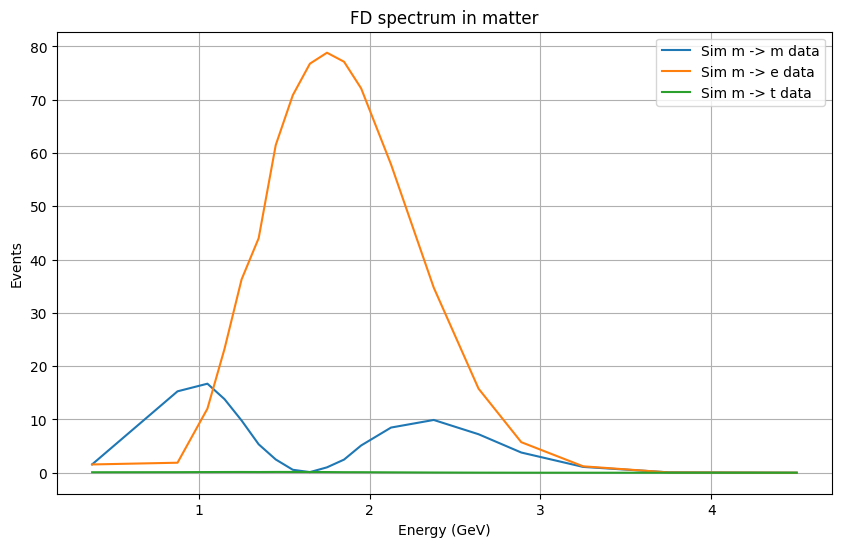

In [398]:
plt.figure(figsize=(10,6))
plt.hist(bin_edges[:-1], bin_edges, weights=sim_counts_fd_mm_matter, histtype='step', label='Sim m -> m data')
plt.hist(bin_edges[:-1], bin_edges, weights=counts_fd, histtype='step', label='Obs m -> m FD data')

plt.title('Observed FD spectrum vs Simulated FD spectrum in matter')
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.grid()
plt.legend()
plt.show()


plt.figure(figsize=(10,6))

plt.plot(bin_centers,sim_counts_fd_mm_matter, label='Sim m -> m data')
plt.plot(bin_centers,sim_counts_fd_mt_matter, label='Sim m -> e data')
plt.plot(bin_centers,sim_counts_fd_me_matter, label='Sim m -> t data')

plt.title("FD spectrum in matter")
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.grid()
plt.legend()
plt.show()

